In [1]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

from dotenv import load_dotenv

import subprocess
import uuid
from pathlib import Path
import os

In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI(
    model="meta-llama/llama-3.3-70b-instruct",
    # model="nvidia/nemotron-3.5-lightning:free",
    temperature=0,
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
)

In [4]:
class ChatState(TypedDict):
    user_message: str
    llm_response: str
    audio_file: str

In [5]:
def chat_node(state: ChatState):

    user_message = state["user_message"]

    response = llm.invoke(user_message)

    return {
        "llm_response": response.content
    }

In [6]:
# AUDIO_DIR = Path("audio")
# AUDIO_DIR.mkdir(exist_ok=True)

# PIPER_EXECUTABLE = Path(
#     ".venv/Scripts/piper.exe"
# )

# PIPER_MODEL = Path(
    
#     "backend/models/en_US-lessac-medium.onnx"
# )

PROJECT_ROOT = Path.cwd().parent

AUDIO_DIR = PROJECT_ROOT / "backend" / "audio"

PIPER_EXECUTABLE = PROJECT_ROOT / ".venv" / "Scripts" / "piper.exe"

PIPER_MODEL = PROJECT_ROOT / "backend" / "models" / "en_US-lessac-medium.onnx"

AUDIO_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [7]:
from pathlib import Path
import os

print("Current working directory:")
print(Path.cwd())

print("\nProject files:")
for path in Path.cwd().iterdir():
    print(path)

Current working directory:
c:\Users\MuneebZafar\Downloads\Personal\Langchain\Projects\Voice Chatbot\notebooks

Project files:
c:\Users\MuneebZafar\Downloads\Personal\Langchain\Projects\Voice Chatbot\notebooks\audio
c:\Users\MuneebZafar\Downloads\Personal\Langchain\Projects\Voice Chatbot\notebooks\langgraph.ipynb
c:\Users\MuneebZafar\Downloads\Personal\Langchain\Projects\Voice Chatbot\notebooks\models.py
c:\Users\MuneebZafar\Downloads\Personal\Langchain\Projects\Voice Chatbot\notebooks\test.ipynb


In [8]:
def piper_node(state: ChatState):

    text = state["llm_response"]

    filename = f"{uuid.uuid4()}.wav"

    output_path = AUDIO_DIR / filename

    command = [
        str(PIPER_EXECUTABLE),
        "--model",
        str(PIPER_MODEL),
        "--output_file",
        str(output_path),
    ]

    subprocess.run(
        command,
        input=text,
        text=True,
        check=True,
    )

    return {
        "audio_file": str(output_path)
    }

In [9]:
builder = StateGraph(ChatState)

In [10]:
builder.add_node(
    "chat",
    chat_node
)

builder.add_node(
    "piper",
    piper_node
)

In [11]:
builder.add_edge(
    START,
    "chat"
)

builder.add_edge(
    "chat",
    "piper"
)

builder.add_edge(
    "piper",
    END
)

In [12]:
graph = builder.compile()

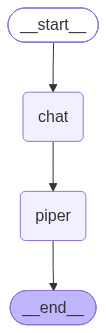

In [13]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [14]:
user_input = "Tell me about yourself"

result = graph.invoke({
    "user_message": user_input,
})

In [15]:
print(result)

{'user_message': 'Tell me about yourself', 'llm_response': 'I\'m an artificial intelligence model known as Llama. Llama stands for "Large Language Model Meta AI."', 'audio_file': 'c:\\Users\\MuneebZafar\\Downloads\\Personal\\Langchain\\Projects\\Voice Chatbot\\backend\\audio\\850dffec-5274-41c6-b640-5fa3de1fdd4c.wav'}


In [16]:
from IPython.display import Audio, display

display(
    Audio(result["audio_file"])
)